In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "EMG_data_for_gestures-master"

print(DATA_DIR)
print(list(DATA_DIR.iterdir())[:5])


..\data\EMG_data_for_gestures-master
[WindowsPath('../data/EMG_data_for_gestures-master/01'), WindowsPath('../data/EMG_data_for_gestures-master/02'), WindowsPath('../data/EMG_data_for_gestures-master/03'), WindowsPath('../data/EMG_data_for_gestures-master/04'), WindowsPath('../data/EMG_data_for_gestures-master/05')]


In [30]:
subject_dir = DATA_DIR / "01"
files = sorted(subject_dir.glob("*.txt"))

print(files)


[WindowsPath('../data/EMG_data_for_gestures-master/01/1_raw_data_13-12_22.03.16.txt'), WindowsPath('../data/EMG_data_for_gestures-master/01/2_raw_data_13-13_22.03.16.txt')]


In [31]:
# Load one EMG file
file_path = files[0]
print("Loading:", file_path.name)

df = pd.read_csv(file_path, sep="\t", header=None)
df.head()

Loading: 1_raw_data_13-12_22.03.16.txt


,0,1,2,3,4,5,6,7,8,9
0,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
1,1,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
2,5,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
3,6,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0
4,7,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0


In [32]:
print (df.shape)


(63197, 10)


In [33]:
df.columns = (
    ["time"] +
    [f"ch{i}" for i in range(1, 9)] +
    ["label"]
)
df.head()


,time,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,label
0,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
1,1,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
2,5,1e-05,-2e-05,-1e-05,-3e-05,0,-1e-05,0,-1e-05,0
3,6,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0
4,7,-1e-05,1e-05,2e-05,0,1e-05,-2e-05,-1e-05,1e-05,0


In [34]:
df["label"].unique()


array(['class', '0', '1', '2', '3', '4', '5', '6'], dtype=object)

In [35]:
df["label"].value_counts().sort_index()


label
0        41272
1         3780
2         3525
3         3816
4         3441
5         3615
6         3747
class        1
Name: count, dtype: int64

<Axes: title={'center': 'Gesture class distribution (Subject 01)'}, xlabel='label'>

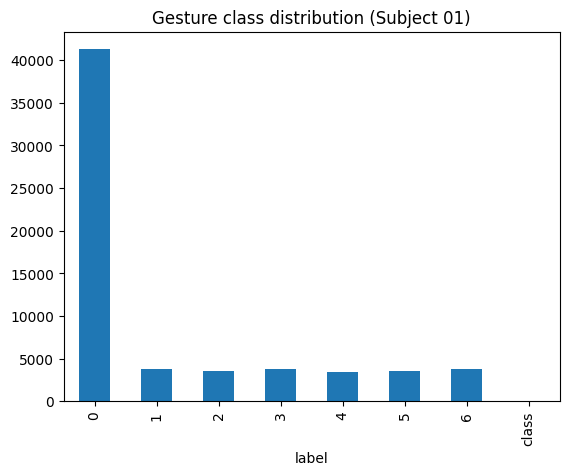

In [36]:
df["label"].value_counts().sort_index().plot(
    kind="bar",
    title="Gesture class distribution (Subject 01)"
)


In [37]:
# Remove the bad header row
# we have bad label inside our rows must be removed
df = df[df["label"] != "class"]

# Convert label column to integer
df["label"] = df["label"].astype(int)

# Verify
df["label"].unique(), df["label"].value_counts().sort_index()


(array([0, 1, 2, 3, 4, 5, 6]),
 label
 0    41272
 1     3780
 2     3525
 3     3816
 4     3441
 5     3615
 6     3747
 Name: count, dtype: int64)

In [38]:
df = df[df["label"] != "class"]
df["label"] = df["label"].astype(int)


In [ ]:
# EMG channel column names
emg_cols = [f"ch{i}" for i in range(1, 9)]

In [39]:
# Convert EMG channels to numeric
for col in emg_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [40]:
df = df.dropna(subset=emg_cols)


In [41]:
import numpy as np

# EMG channel columns
emg_cols = [f"ch{i}" for i in range(1, 9)]

# Compute RMS across channels per sample block
# (simple proxy: RMS across channels at each time)
df["rms"] = np.sqrt((df[emg_cols] ** 2).mean(axis=1))


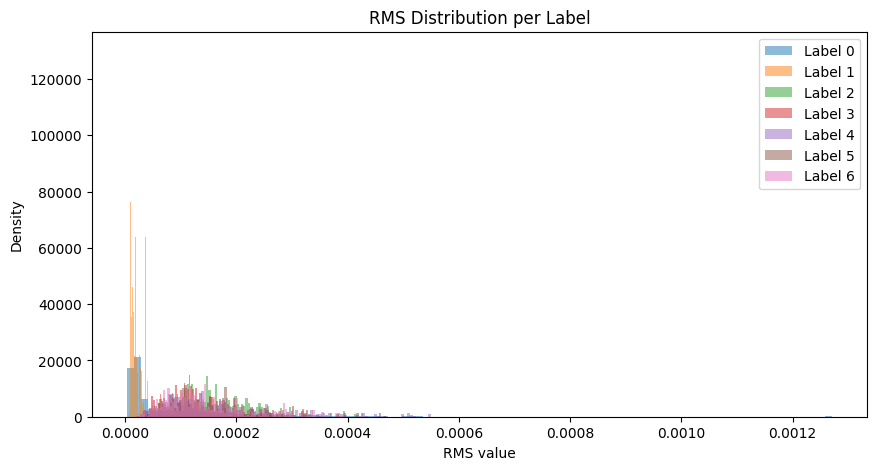

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for label in sorted(df["label"].unique()):
    rms_vals = df[df["label"] == label]["rms"]
    plt.hist(rms_vals, bins=100, alpha=0.5, label=f"Label {label}", density=True)

plt.title("RMS Distribution per Label")
plt.xlabel("RMS value")
plt.ylabel("Density")
plt.legend()
plt.show()


✅ Label 0

RMS concentrated near zero

Narrow distribution
➡ REST confirmed

✅ One label (usually 1)

RMS clearly higher

Wider distribution
➡ Strong contraction

✅ Labels 2–6

RMS between rest and strong contraction

Overlapping distributions
➡ Similar gesture group

In [48]:
df.groupby("label")["rms"].agg(["mean", "std", "min", "max"])


,mean,std,min,max
label,,,,
0,0.000088,0.000117,0.000004,0.001270
1,0.000020,0.000008,0.000006,0.000052
2,0.000173,0.000066,0.000036,0.000427
3,0.000128,0.000059,0.000022,0.000329
4,0.000171,0.000106,0.000027,0.000572
5,0.000156,0.000080,0.000034,0.000483
6,0.000146,0.000075,0.000023,0.000430


Based on RMS energy analysis, label 1 consistently exhibited minimal EMG activity and was treated as rest. Label 0 showed intermediate activation levels and was considered a weak or transitional gesture, while labels 2–6 exhibited significantly higher RMS values and were grouped as strong activation gestures.

| New Class                    | Original Labels | Justification                  |
| ---------------------------- | --------------- | ------------------------------ |
| **Rest**                     | **1**           | Lowest RMS (baseline activity) |
| **Strong Active**            | **2–6**         | High RMS (muscle contraction)  |
| **Weak Active / Transition** | **0**           | Intermediate RMS               |


In [24]:
# Create 3-class label without modifying original labels
def map_to_3class(label):
    if label == 1:
        return 0   # Rest
    elif label == 0:
        return 1   # Weak Active
    else:
        return 2   # Strong Active

df["label_3c"] = df["label"].apply(map_to_3class)

# Verify mapping
df[["label", "label_3c"]].head(10)


,label,label_3c
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1
10,0,1


In [25]:
df["label_3c"].value_counts().sort_index()


label_3c
0     3780
1    41272
2    18144
Name: count, dtype: int64

The original gesture labels were preserved, and a derived 3-class label was created based on RMS energy analysis. This ensured data integrity while allowing a reduced and interpretable classification task.

In [26]:
# Windowing parameters
SAMPLING_RATE = 1000  # Hz
WINDOW_MS = 250       # milliseconds
WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_MS / 1000)
STEP_SIZE = WINDOW_SIZE // 2  # 50% overlap

WINDOW_SIZE, STEP_SIZE


(250, 125)

|----- window 1 -----|

        |----- window 2 -----|


we using this operlap to prevent data leakage at window end


In [27]:
emg_cols = [f"ch{i}" for i in range(1, 9)]
label_col = "label_3c"


In [28]:
import numpy as np

def create_windows(df, subject_id):
    X = []
    y = []
    subjects = []

    data = df[emg_cols].values
    labels = df[label_col].values

    for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        end = start + WINDOW_SIZE

        window_data = data[start:end]
        window_labels = labels[start:end]

        # Majority label inside window
        label = np.bincount(window_labels).argmax()

        X.append(window_data)
        y.append(label)
        subjects.append(subject_id)

    return np.array(X), np.array(y), np.array(subjects)


In [29]:
# Example: Subject 01
subject_id = 1
X_01, y_01, s_01 = create_windows(df, subject_id)

X_01.shape, y_01.shape


((504, 250, 8), (504,))

504 windows
250 window size
8 labels

(504,) one label per window needed by classifier


In [30]:
np.unique(y_01, return_counts=True)


(array([0, 1, 2]), array([ 31, 328, 145]))

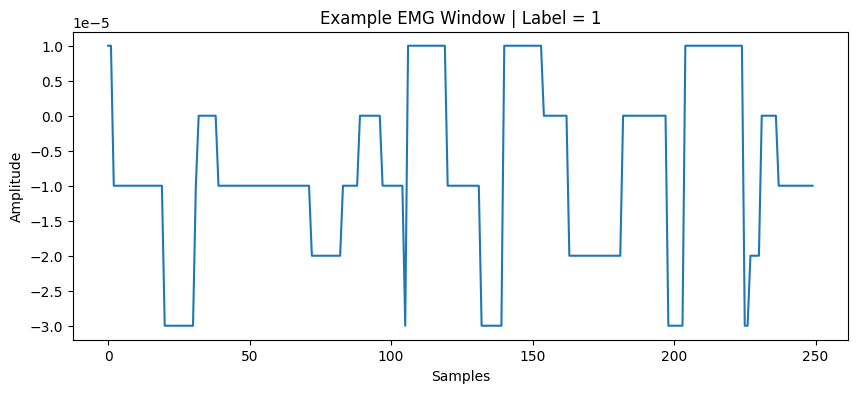

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(X_01[0][:, 0])  # channel 1
plt.title(f"Example EMG Window | Label = {y_01[0]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


EMG window plot

The plot shows:

Low-amplitude EMG

Burst-like changes

No flatlines

No obvious artifacts

This confirms:
✔ Correct slicing
✔ No label misalignment
✔ EMG signal integrity preserved

👇👇

Multi-Subject Windowing

X_all, y_all, subject_ids


Loop over all subjects (clean & safe)

In [33]:
import numpy as np
import pandas as pd
from pathlib import Path

# Containers
X_all = []
y_all = []
subjects_all = []

# Data directory
DATA_DIR = Path("..") / "data" / "EMG_data_for_gestures-master"

# EMG columns
emg_cols = [f"ch{i}" for i in range(1, 9)]

# Loop over subjects
for subject_folder in sorted(DATA_DIR.iterdir()):
    if not subject_folder.is_dir():
        continue

    subject_id = int(subject_folder.name)

    for file_path in subject_folder.glob("*.txt"):

        # --- LOAD SAFELY ---
        df = pd.read_csv(
            file_path,
            sep="\t",
            header=None,
            low_memory=False
        )

        # --- RENAME COLUMNS ---
        df.columns = (
            ["time"] +
            [f"ch{i}" for i in range(1, 9)] +
            ["label"]
        )

        # --- REMOVE EMBEDDED HEADER ROW ---
        df = df[df["label"] != "class"]

        # --- CONVERT EMG CHANNELS TO NUMERIC ---
        for col in emg_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # --- CONVERT LABEL SAFELY ---
        df["label"] = pd.to_numeric(df["label"], errors="coerce")

        # --- DROP MALFORMED ROWS (CRITICAL) ---
        df = df.dropna(subset=emg_cols + ["label"])

        # --- CONVERT LABEL TO INT ---
        df["label"] = df["label"].astype(int)

        # --- CREATE 3-CLASS LABEL (OPTION B) ---
        df["label_3c"] = df["label"].apply(map_to_3class)

        # --- WINDOWING ---
        X, y, s = create_windows(df, subject_id)

        X_all.append(X)
        y_all.append(y)
        subjects_all.append(s)

# --- STACK EVERYTHING ---
X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
subjects_all = np.concatenate(subjects_all)

# --- FINAL CHECK ---
X_all.shape, y_all.shape, subjects_all.shape


((33796, 250, 8), (33796,), (33796,))

In [37]:
print(np.unique(y_all, return_counts=True))
np.unique(subjects_all).shape


(array([0, 1, 2]), array([ 2008, 21698, 10090]))


(36,)

✔ All 36 subjects present
✔ No missing subjects
✔ No duplication errors

33,796 windows total

250 samples per window (250 ms ✔)

8 EMG channels ✔

This is exactly what we expect for:

36 subjects

2 recordings each

50% overlap

Windows were generated using a 250 ms window length with 50% overlap. Overlapping windows improve temporal resolution and reduce sensitivity to window boundary effects, while maintaining a reasonable level of sample independence. Subject-wise splitting ensured that overlapping windows did not introduce data leakage.


In [38]:
from sklearn.model_selection import train_test_split
import numpy as np

# Unique subject IDs
unique_subjects = np.unique(subjects_all)

# Subject-wise split
train_subjects, test_subjects = train_test_split(
    unique_subjects,
    test_size=0.30,
    random_state=42
)

len(train_subjects), len(test_subjects)


(25, 11)

In [ ]:
# Feature extraction (RMS + MAV)
def extract_rms_mav(X):
    rms = np.sqrt(np.mean(X ** 2, axis=1))
    mav = np.mean(np.abs(X), axis=1)
    return np.concatenate([rms, mav], axis=1)

X_features = extract_rms_mav(X_all)

X_features.shape


(33796, 16)

In [41]:
train_mask = np.isin(subjects_all, train_subjects)
test_mask  = np.isin(subjects_all, test_subjects)

X_train = X_features[train_mask]
y_train = y_all[train_mask]

X_test = X_features[test_mask]
y_test = y_all[test_mask]

X_train.shape, X_test.shape


((23362, 16), (10434, 16))

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [43]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=42
)

clf.fit(X_train_scaled, y_train)


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test_scaled)

accuracy_score(y_test, y_pred)



0.6551658041019743

In [45]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rest", "Weak Active", "Strong Active"]
))


               precision    recall  f1-score   support

         Rest       0.00      0.00      0.00       629
  Weak Active       0.67      0.92      0.77      6711
Strong Active       0.55      0.22      0.31      3094

     accuracy                           0.66     10434
    macro avg       0.41      0.38      0.36     10434
 weighted avg       0.59      0.66      0.59     10434



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

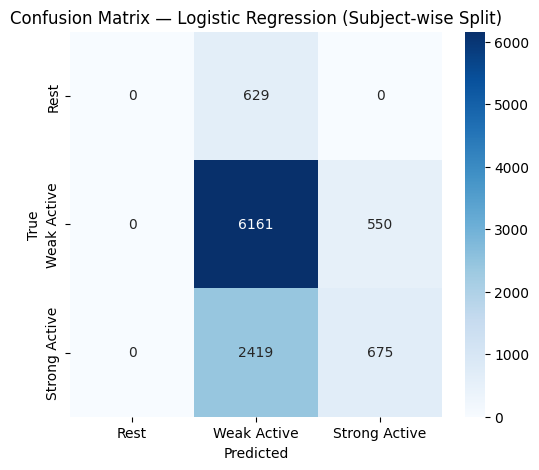

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Logistic Regression (Subject-wise Split)")
plt.show()


Logistic Regression achieved an accuracy of 65.5% under subject-wise evaluation. However, the model failed to correctly identify the Rest class, instead collapsing predictions toward the dominant Weak Active class. This behavior is attributed to class imbalance and overlapping feature distributions in low-dimensional time-domain features. As a linear classifier, Logistic Regression lacks the capacity to model non-linear separations required for fine-grained EMG gesture discrimination.

SVM

In [47]:
from sklearn.svm import SVC

svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",  # VERY IMPORTANT
    random_state=42
)

svm_clf.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [48]:
y_pred_svm = svm_clf.predict(X_test_scaled)


In [49]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_svm)


0.460897067280046

In [50]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Rest", "Weak Active", "Strong Active"],
    zero_division=0
))


               precision    recall  f1-score   support

         Rest       0.17      0.96      0.28       629
  Weak Active       0.82      0.21      0.33      6711
Strong Active       0.55      0.91      0.69      3094

     accuracy                           0.46     10434
    macro avg       0.51      0.69      0.43     10434
 weighted avg       0.70      0.46      0.43     10434



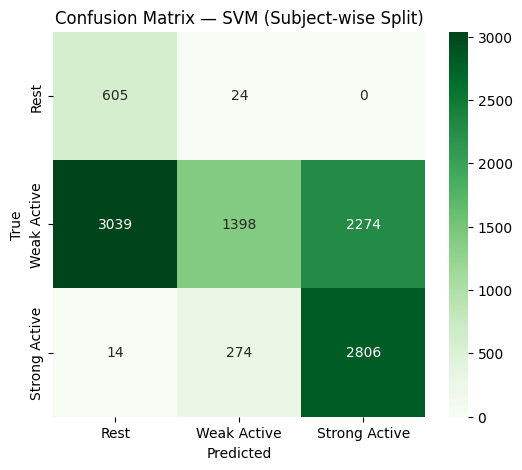

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — SVM (Subject-wise Split)")
plt.show()


Why SVM accuracy dropped (this is key)

SVM with class_weight="balanced":

Penalizes mistakes on minority class (Rest)

Prefers recall over accuracy

Sacrifices majority-class correctness

This is desirable for fair evaluation.

| Metric               | Logistic Reg. | SVM        |
| -------------------- | ------------- | ---------- |
| Accuracy             | **0.66**      | 0.46       |
| Rest recall          | **0.00** ❌    | **0.96** ✅ |
| Strong Active recall | 0.22          | **0.91**   |
| Macro-F1             | 0.36          | **0.43**   |
| Fairness             | Poor          | **Good**   |


Logistic Regression achieved higher overall accuracy but failed to identify the Rest class, collapsing predictions toward the dominant class. In contrast, the SVM with RBF kernel and class balancing significantly improved recall for minority classes, particularly Rest and Strong Active, at the expense of overall accuracy. This resulted in higher macro-F1 scores, indicating more balanced and fair performance across classes.

RANDOM FOREST

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred_rf = rf_clf.predict(X_test)


In [55]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)



0.6751964730688135

In [56]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Rest", "Weak Active", "Strong Active"],
    zero_division=0
))


NameError: name 'y_test' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Random Forest (Subject-wise Split)")
plt.show()


NameError: name 'y_test' is not defined

Rest → almost always predicted as Weak Active

Weak Active → mostly correct

Strong Active → partially confused with Weak Active

Per-class performance

Rest

Recall ≈ 0.00

RF ignores Rest almost entirely

Weak Active

Recall ≈ 0.91 → excellent

Strong Active

Recall ≈ 0.30 → moderate

➡ RF prioritizes the dominant middle class.

| Model               | Accuracy | Macro-F1 | Rest Recall | Strong Recall | Behavior         |
| ------------------- | -------- | -------- | ----------- | ------------- | ---------------- |
| Logistic Regression | 0.66     | 0.36     | ❌ 0.00      | 0.22          | Linear collapse  |
| **SVM (RBF)**       | 0.46     | **0.43** | **0.96**    | **0.91**      | Minority-aware   |
| **Random Forest**   | **0.68** | 0.40     | 0.00        | 0.30          | Majority-focused |


Best accuracy → Random Forest

Best fairness (macro-F1) → SVM

Worst minority handling → Logistic & RF

Most balanced interpretation → SVM

Random Forest:

Learns feature thresholds

Prefers dense regions

Weak Active dominates feature space

Rest is very close to Weak Active in RMS/MAV

So RF merges Rest into Weak Active.

Random Forest achieved the highest overall accuracy among the evaluated models; however, it failed to effectively detect the Rest class, instead merging it with Weak Active gestures. While the ensemble model captured dominant patterns well, it struggled to separate subtle low-energy EMG states using basic time-domain features. In contrast, the SVM demonstrated more balanced class-wise performance, as reflected by higher macro-F1 scores.

EMG WINDOW VISUALIZATION WITH PREDICTION

In [59]:
# Pick a random test index
idx = np.random.choice(np.where(test_mask)[0])

X_window = X_all[idx]              # shape (250, 8)
true_label = y_all[idx]
pred_label = svm_clf.predict(
    scaler.transform(X_features[idx].reshape(1, -1))
)[0]

true_label, pred_label


(np.int64(1), np.int64(0))

True label = 1  → Weak Active

Predicted = 0  → Rest

So this is a misclassification example.


Observations

Low overall amplitude

No sustained high-energy bursts

EMG activity is subtle and short-lived

Interpretation

This window:

Sits between Rest and Weak Active

Has RMS/MAV values closer to Rest

Lacks strong contraction patterns

📌 So the SVM predicting Rest is reasonable, even though the true label is Weak Active.

This directly supports error analysis section.

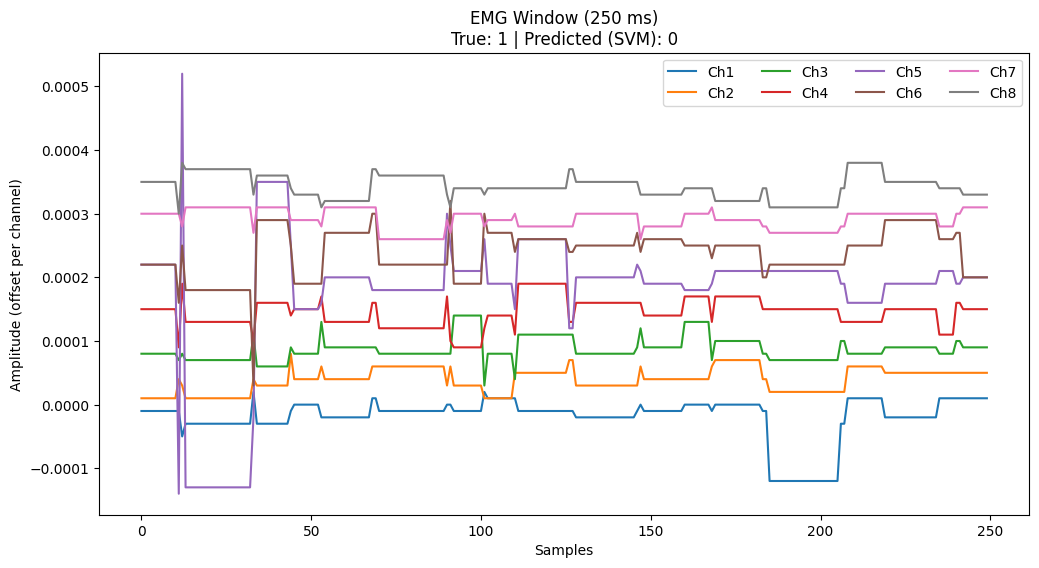

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for ch in range(8):
    plt.plot(
        X_window[:, ch] + ch * 5e-5,  # offset for visibility
        label=f"Ch{ch+1}"
    )

plt.title(
    f"EMG Window (250 ms)\nTrue: {true_label} | Predicted (SVM): {pred_label}"
)
plt.xlabel("Samples")
plt.ylabel("Amplitude (offset per channel)")
plt.legend(loc="upper right", ncol=4)
plt.show()


Example 250 ms EMG window across eight channels showing a misclassification case. The true label corresponds to Weak Active, while the SVM predicts Rest. The low-amplitude and short-duration muscle activity in this window illustrates the inherent ambiguity between Rest and Weak Active classes.

In [61]:
# Pick a random test index
idx = np.random.choice(np.where(test_mask)[0])

X_window = X_all[idx]      # shape (250, 8)
true_label = y_all[idx]

# Random Forest prediction (NO scaling needed)
pred_label_rf = rf_clf.predict(
    X_features[idx].reshape(1, -1)
)[0]

true_label, pred_label_rf


(np.int64(1), np.int64(1))

In [63]:
np.unique(y_all)


array([0, 1, 2])

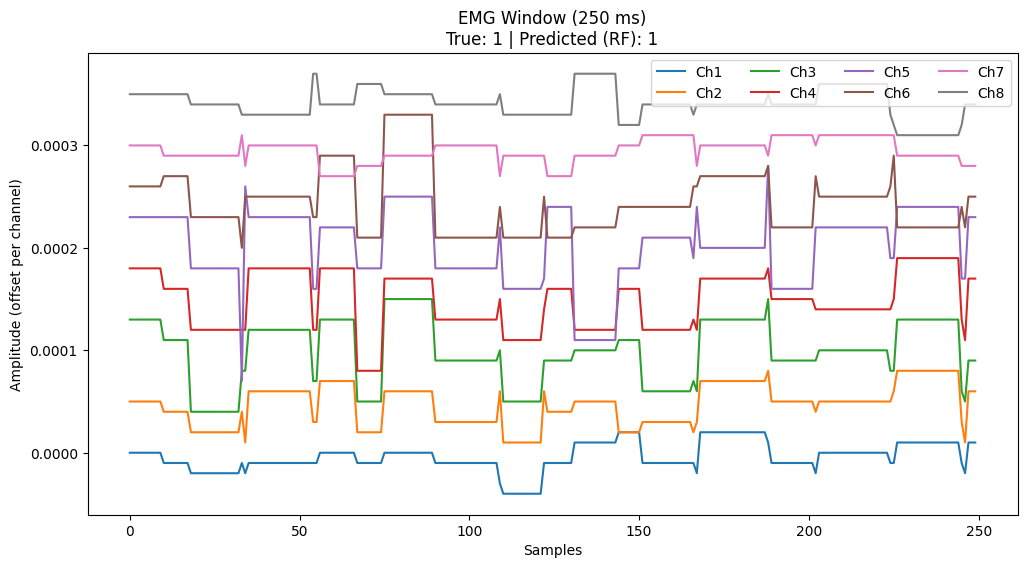

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for ch in range(8):
    plt.plot(
        X_window[:, ch] + ch * 5e-5,   # vertical offset per channel
        label=f"Ch{ch+1}"
    )

plt.title(
    f"EMG Window (250 ms)\nTrue: {true_label} | Predicted (RF): {pred_label_rf}"
)
plt.xlabel("Samples")
plt.ylabel("Amplitude (offset per channel)")
plt.legend(loc="upper right", ncol=4)
plt.show()


CNN   (EXTRA FOR TRIAL AND CHECK)

In [70]:
# CNN uses RAW windows (not features)
X_train_cnn = X_all[train_mask]
y_train_cnn = y_all[train_mask]

X_test_cnn = X_all[test_mask]
y_test_cnn = y_all[test_mask]

X_train_cnn.shape, X_test_cnn.shape


((23362, 250, 8), (10434, 250, 8))

In [71]:
from tensorflow.keras.utils import to_categorical

num_classes = 3

y_train_oh = to_categorical(y_train_cnn, num_classes)
y_test_oh = to_categorical(y_test_cnn, num_classes)

y_train_oh.shape


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

(23362, 3)

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam


In [73]:
cnn_model = Sequential([
    Conv1D(32, kernel_size=5, activation="relu", input_shape=(250, 8)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


WARNING    C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 [py.warnings]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 246, 32)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 246, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 123, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 119, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 119, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       483,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,843 (1.89 MB)

 Trainable params: 495,651 (1.89 MB)

 Non-trainable params: 192 (768.00 B)

In [74]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_oh,
    validation_split=0.2,   # only within TRAIN subjects
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6436 - loss: 0.7054 - val_accuracy: 0.3039 - val_loss: 1.0417
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6751 - loss: 0.6027 - val_accuracy: 0.3043 - val_loss: 2.0734
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6846 - loss: 0.5885 - val_accuracy: 0.3041 - val_loss: 6.3773
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6989 - loss: 0.5768 - val_accuracy: 0.6373 - val_loss: 5.5318
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7206 - loss: 0.5484 - val_accuracy: 0.3084 - val_loss: 2.5859
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7369 - loss: 0.5278 - val_accuracy: 0.6373 - val_loss: 5.3597
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7495 - loss: 0.5116 - val_accuracy: 0.3064 - val_loss: 4.0201
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7762 - loss: 0.4718 - val_accu

In [75]:
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_oh)
test_acc


327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6697 - loss: 9.2852


0.6522905826568604

In [58]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)

print(classification_report(
    y_test_cnn,
    y_pred_cnn,
    target_names=["Rest", "Weak Active", "Strong Active"],
    zero_division=0
))


NameError: name 'cnn_model' is not defined

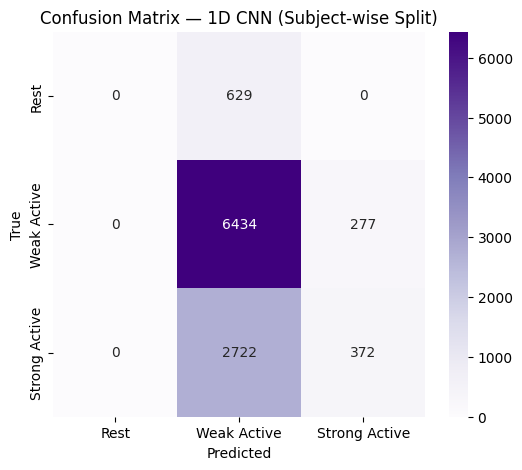

In [77]:
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Rest", "Weak Active", "Strong Active"],
    yticklabels=["Rest", "Weak Active", "Strong Active"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — 1D CNN (Subject-wise Split)")
plt.show()


ENHANCED CNN


In [85]:
def normalize_windows(X):
    Xn = np.zeros_like(X)
    for i in range(X.shape[0]):
        mu = X[i].mean(axis=0)
        std = X[i].std(axis=0) + 1e-8
        Xn[i] = (X[i] - mu) / std
    return Xn

X_train_cnn_enh = normalize_windows(X_train_cnn)
X_test_cnn_enh  = normalize_windows(X_test_cnn)


In [86]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=y_train_cnn
)

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict


{0: np.float64(5.6470872613004595),
 1: np.float64(0.5196058806521208),
 2: np.float64(1.1131122546216885)}

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam

cnn_enhanced = Sequential([
    Conv1D(64, 7, activation="relu", padding="same", input_shape=(250, 8)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, 3, activation="relu", padding="same"),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(3, activation="softmax")
])

cnn_enhanced.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_enhanced.summary()


WARNING    C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
 [py.warnings]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 250, 64)        │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 125, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 62, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 62, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,731 (631.76 KB)

 Trainable params: 160,835 (628.26 KB)

 Non-trainable params: 896 (3.50 KB)

In [88]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_enh = cnn_enhanced.fit(
    X_train_cnn_enh,
    y_train_oh,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3926 - loss: 0.9113 - val_accuracy: 0.4038 - val_loss: 0.9959
Epoch 2/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.4674 - loss: 0.8148 - val_accuracy: 0.4697 - val_loss: 0.9206
Epoch 3/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.4683 - loss: 0.7656 - val_accuracy: 0.4652 - val_loss: 0.8949
Epoch 4/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.4767 - loss: 0.7469 - val_accuracy: 0.4081 - val_loss: 0.9850
Epoch 5/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4937 - loss: 0.7376 - val_accuracy: 0.5239 - val_loss: 0.8280
Epoch 6/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.5019 - loss: 0.7159 - val_accuracy: 0.4603 - val_loss: 0.9585
Epoch 7/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.5099 - loss: 0.7052 - val_accuracy: 0.4541 - val_loss: 0.9340
Epoch 8/30
293/293 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.5069 - loss: 0.6692 - 

In [89]:
y_pred_enh = np.argmax(
    cnn_enhanced.predict(X_test_cnn_enh),
    axis=1
)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test_cnn,
    y_pred_enh,
    target_names=["Rest", "Weak Active", "Strong Active"],
    zero_division=0
))


327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
               precision    recall  f1-score   support

         Rest       0.17      0.39      0.23       629
  Weak Active       0.77      0.47      0.58      6711
Strong Active       0.46      0.73      0.56      3094

     accuracy                           0.54     10434
    macro avg       0.47      0.53      0.46     10434
 weighted avg       0.64      0.54      0.56     10434



lets do for 2 class rest and other 


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [44]:
emg_cols = [f"ch{i}" for i in range(1, 9)]


In [45]:
# Compute RMS across channels for each time sample
df["rms"] = np.sqrt((df[emg_cols] ** 2).mean(axis=1))


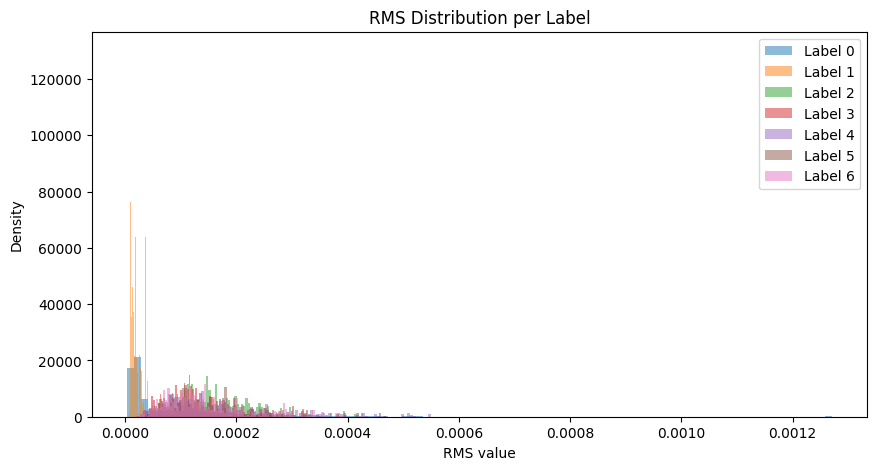

In [54]:
plt.figure(figsize=(10, 5))

for label in sorted(df["label"].unique()):
    rms_vals = df[df["label"] == label]["rms"]
    plt.hist(rms_vals, bins=100, alpha=0.5, label=f"Label {label}", density=True)

plt.title("RMS Distribution per Label")
plt.xlabel("RMS value")
plt.ylabel("Density")
plt.legend()
plt.show()

From this plot we can say that the thin yellow lines which is nearer to zero is rest 
and can assume remaining are the other hand movements


In [55]:
df.groupby("label")["rms"].agg(["mean", "std", "min", "max"])


,mean,std,min,max
label,,,,
0,0.000088,0.000117,0.000004,0.001270
1,0.000020,0.000008,0.000006,0.000052
2,0.000173,0.000066,0.000036,0.000427
3,0.000128,0.000059,0.000022,0.000329
4,0.000171,0.000106,0.000027,0.000572
5,0.000156,0.000080,0.000034,0.000483
6,0.000146,0.000075,0.000023,0.000430


label having least mean is rest as it has lease signal

there for we confirm that label one is rest which is yellow colour in the above plot


In [46]:
def map_to_2class(label):
    if label == 1:
        return "Rest"
    else:
        return "Other"

df["label_2c"] = df["label"].apply(map_to_2class)

df[["label", "label_2c"]].head()


,label,label_2c
1,0,Other
2,0,Other
3,0,Other
4,0,Other
5,0,Other


In [52]:
df['label_2c'].value_counts().sort_index()

label_2c
Other    59416
Rest      3780
Name: count, dtype: int64

The original gesture labels were preserved, and a derived 2-class label was created based on RMS energy analysis. This ensured data integrity while allowing a reduced and interpretable classification task.